<a href="https://colab.research.google.com/github/hyunbin1024/GEOG761/blob/lab2/761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [1]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet
!pip install mss --quiet

In [2]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='basic-thinker-504003-q7')

In [3]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [4]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [5]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

s2_max = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .max() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

s2_min = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .min() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

s2_mosaic = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .mosaic() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

In [6]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(s2_max, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 Max')
Map.addLayer(s2_min, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 Min')
Map.addLayer(s2_mosaic, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 Mosaic')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [7]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thinking there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [8]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [9]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [10]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [11]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [12]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [13]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)

# Define a common visualization palette and labels for WorldCover classes
landcover_names = [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare / sparse vegetation",
    "Snow and ice",
    "Permanent water bodies",
    "Herbaceous wetland",
    "Moss and lichen"
]

# Colors in hexadecimal format for the legend and visualization.
landcover_colors = [
    "006400",
    "ffbb22",
    "ffff4c",
    "f096ff",
    "fa0000",
    "b4b4b4",
    "f0f0f0",
    "0064c8",
    "0096a0",
    "fae6a0"
]

# Create a dictionary for the legend, mapping labels to colors.
legend_dict = dict(zip(landcover_names, landcover_colors))

# Visualization parameters for classified and remapped landcover
# The min and max correspond to the remapped class values (1-10)
classified_viz = {
    'min': 1,
    'max': 10,
    'palette': landcover_colors
}

# Add the classified layer with the defined visualization
Map.addLayer(classified, classified_viz, 'Classified')
# Add the ESA Landcover layer with the same defined visualization for consistency
Map.addLayer(landcover_remapped, classified_viz ,'ESA Landcover')

# Add legends for each layer
# Using the same legend_dict as both layers represent the same classification scheme.
Map.add_legend(title="RF Classified Landcover", legend_dict=legend_dict, position='bottomleft')
Map.add_legend(title="ESA WorldCover Landcover", legend_dict=legend_dict, position='bottomright')

Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


### Test Set Accuracy for 2020 Data

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Classify the test set
tested = test.classify(classifier, 'predicted')

# Get predicted vs actual from test set
y_true_test, y_pred_test = fc_to_lists(tested, 'Map_remapped', 'predicted')

# Labels for original classes (reusing from Zsjs-kDeeRMz)
# label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
# label_names = [label_map[i + 1] for i in range(10)] # These are already defined after running Zsjs-kDeeRMz

# Confusion matrix for test set
cm_test = confusion_matrix(y_true_test, y_pred_test, labels=list(range(1, 11)))
report_test = classification_report(y_true_test, y_pred_test, labels=list(range(1, 11)), target_names=[str(l) for l in label_names], zero_division=0)

# Pretty-print test confusion matrix and classification report
print("Test Confusion Matrix:")
print(pd.DataFrame(cm_test, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nTest Classification Report:")
print(report_test)

Test Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10        94        0        9        0        3        0        0   
Actual 20         0        0        0        0        0        0        0   
Actual 30        21        0       64        0        0        0        0   
Actual 40         0        0        1        0        0        0        0   
Actual 50         3        0        1        0       15        1        0   
Actual 60         0        0        0        0        2        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        1        0        0   
Actual 90         1        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual

---

### Landcover Maps for 2018, 2022, and 2024

Next, I will generate the classified landcover maps for 2018, 2022, and 2024 using the same Random Forest classifier trained on 2020 data. Each map will be displayed with its respective legend.

In [16]:
import geemap
import geopandas as gpd
import pandas as pd
from IPython.display import Image # Import Image for displaying static files
import os # Import the os module for path operations
import numpy as np

# Function to generate and classify Sentinel-2 image for a given year
def get_classified_image_for_year(year, aoi, classifier, bands, mask_s2_clouds):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'

    s2_collection_year = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                          .filterBounds(aoi)
                          .filterDate(start_date, end_date)
                          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
                          .map(mask_s2_clouds)
                          .median() # Use median composite as in the original setup
                          .clip(aoi))

    # Classify the image for the current year
    classified_year = s2_collection_year.select(bands).classify(classifier)

    # Convert ee.Image to numpy array using geemap's utility
    # We use scale=30 to reduce memory footprint. Original scale was 10.
    # 'classification' is the default band name for ee.Classifier.classify output.
    try:
        classified_np_array = geemap.ee_to_numpy(classified_year, region=aoi, bands=['classification'], scale=30)
        # Squeeze to remove the single-band dimension if present (e.g., (H, W, 1) -> (H, W))
        classified_np_array = np.squeeze(classified_np_array)
        return classified_np_array, classified_year
    except Exception as e:
        print(f"Error converting Earth Engine image to NumPy for {year}: {e}")
        return None, None


In [17]:
!pip install matplotlib-scalebar --quiet

Processing 2018...
Processing 2022...
Processing 2024...
Generated publication-quality figure: output_maps/classified_landcover_figure_publication_quality.png


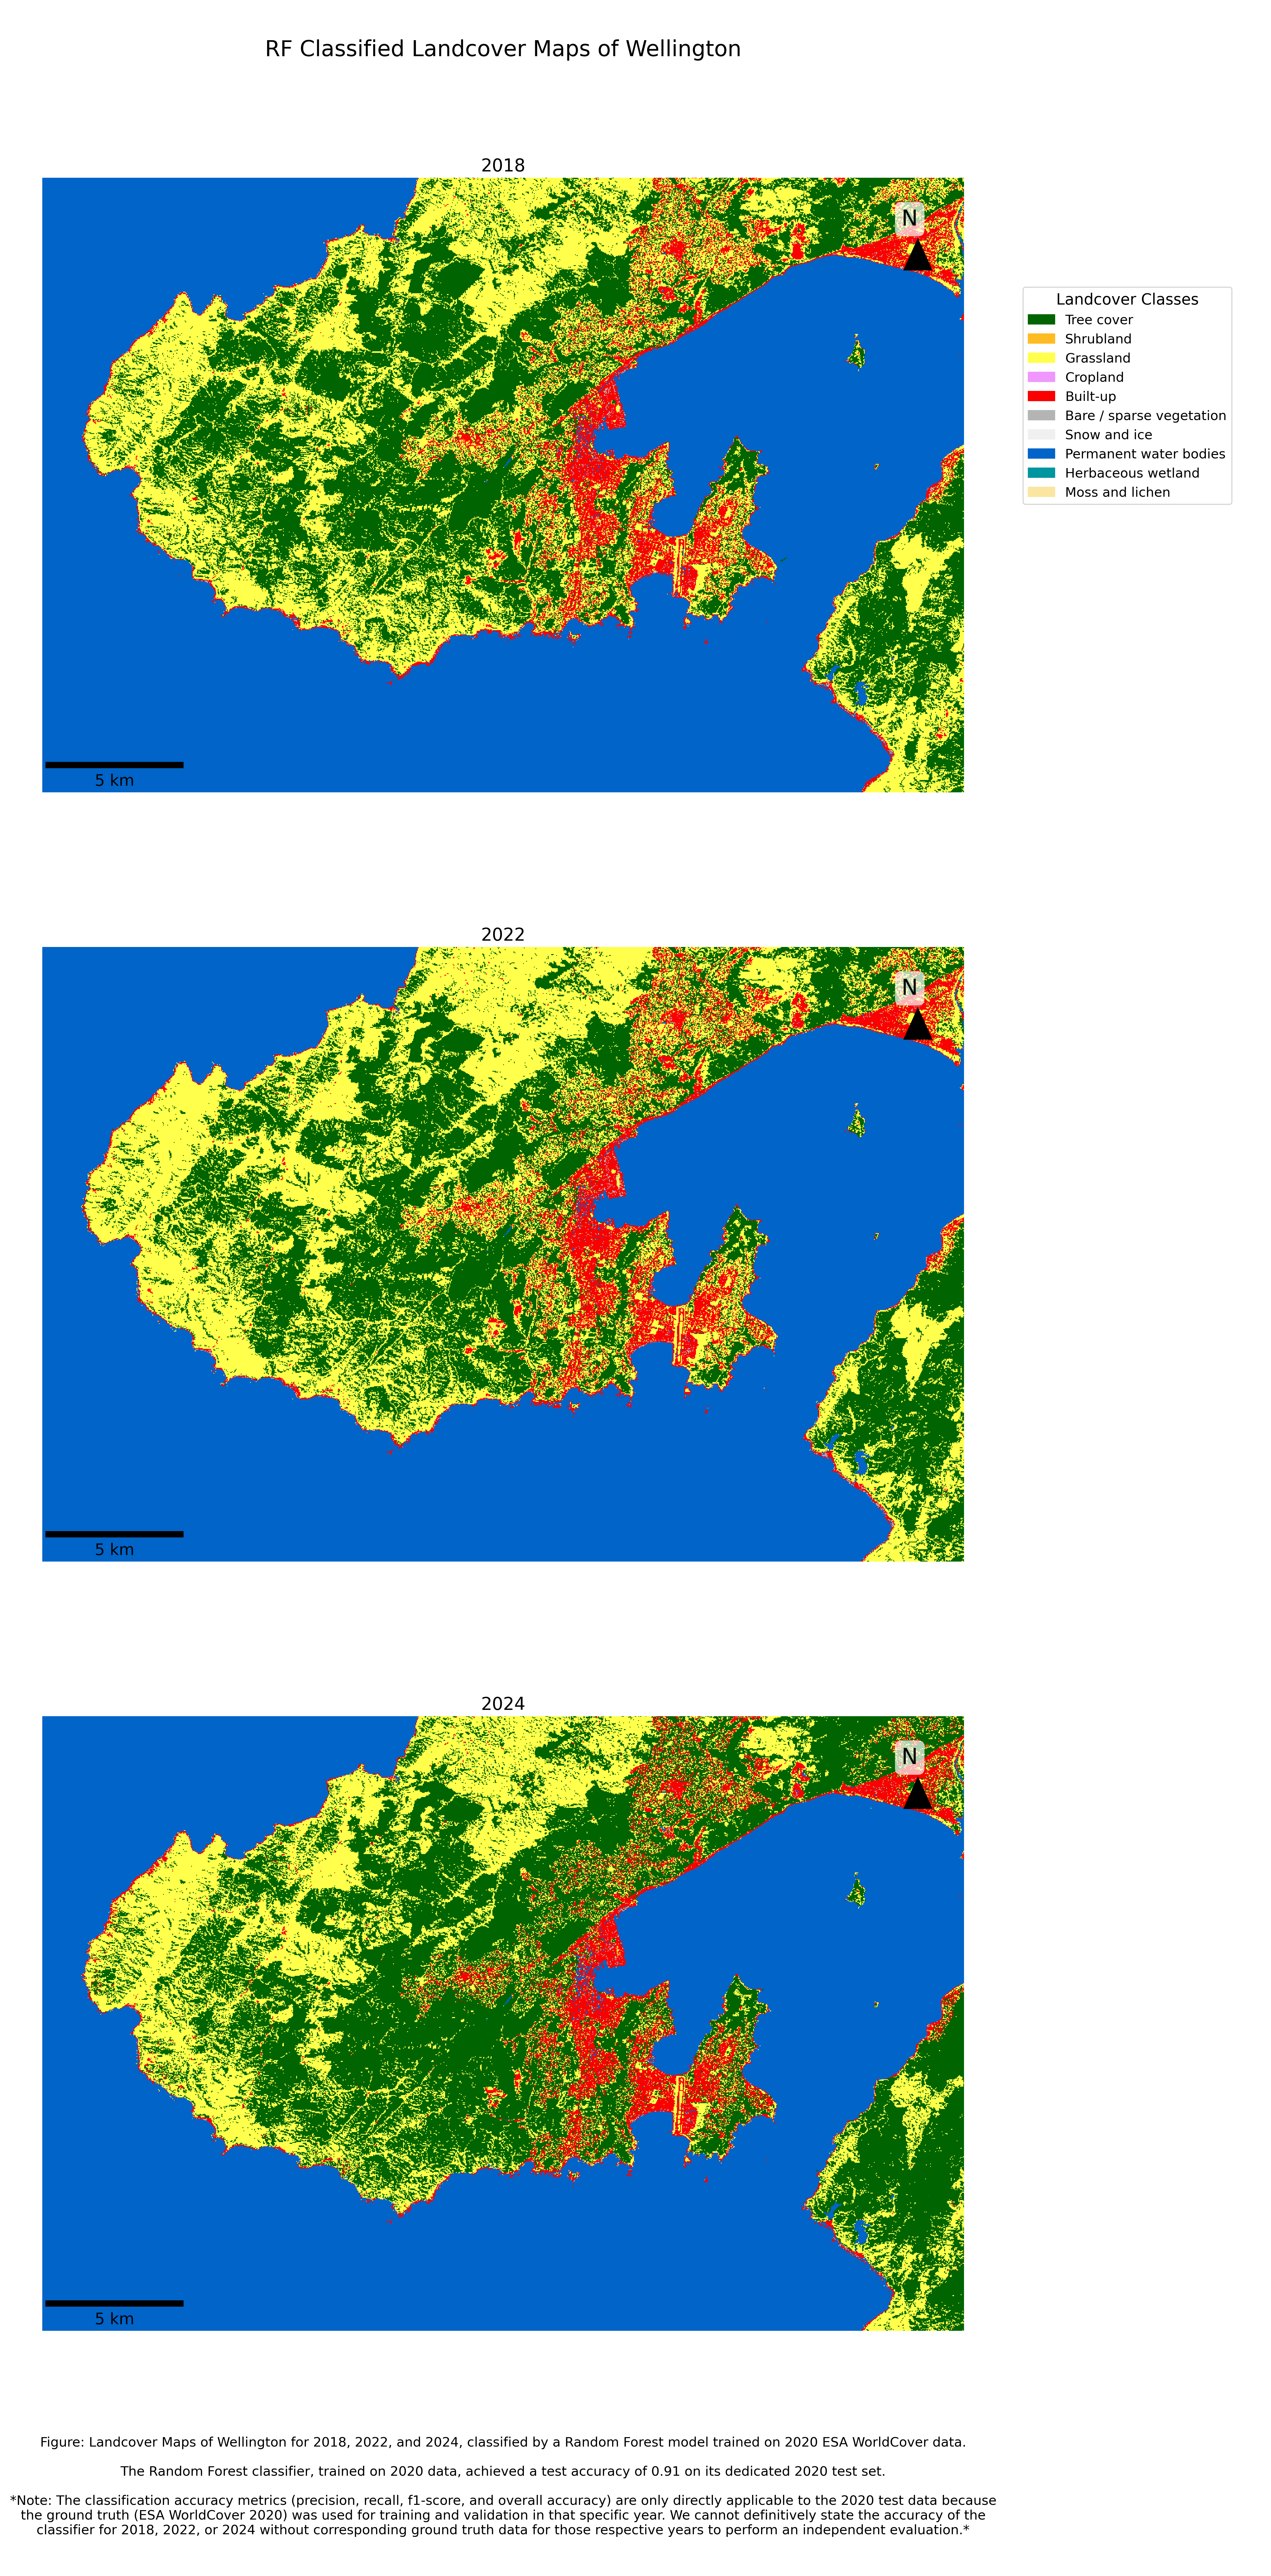

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
from IPython.display import Image
from matplotlib_scalebar.scalebar import ScaleBar # Corrected Import ScaleBar

# Define the years for which to generate maps
years = [2018, 2022, 2024]

# Prepare data for plotting
classified_np_arrays = {}
for year in years:
    print(f"Processing {year}...")
    # Call the refactored function
    np_array, ee_image = get_classified_image_for_year(year, aoi, classifier, bands, mask_s2_clouds)
    if np_array is not None:
        classified_np_arrays[year] = np_array
    else:
        print(f"Could not get classified data for {year}.")

# Only proceed if we have data for all years
if len(classified_np_arrays) == len(years):
    # Create a colormap from the hex colors defined in landcover_colors
    cmap = mcolors.ListedColormap([f'#{c}' for c in landcover_colors])
    # Define bounds for each class (1 to 10 for 10 classes)
    bounds = np.arange(1, len(landcover_names) + 2) # Bounds for 10 classes: [1, 2, ..., 11]
    norm = mcolors.BoundaryNorm(bounds, cmap.N) # Normalize the color mapping

    # Create the figure with 3 subplots arranged vertically
    fig, axes = plt.subplots(3, 1, figsize=(12, 30), sharex=True, sharey=True)
    fig.suptitle('RF Classified Landcover Maps of Wellington', fontsize=20, y=1.005)

    for i, year in enumerate(years):
        ax = axes[i]
        im = ax.imshow(classified_np_arrays[year], cmap=cmap, norm=norm)
        ax.set_title(f'{year}', fontsize=16)
        ax.axis('off') # Turn off axes for a cleaner map look

        # Add scale bar (30 meters per pixel, as specified in ee_to_numpy scale)
        # Removed 'length_factor' as it caused a TypeError
        scalebar = ScaleBar(30, units="m", location='lower left', frameon=False, box_alpha=0, font_properties={'size': 'x-large'})
        ax.add_artist(scalebar)

        # Add north arrow (simple text annotation)
        ax.text(0.95, 0.95, 'N', transform=ax.transAxes, fontsize=20, va='top', ha='right',
                bbox=dict(boxstyle="round,pad=0.3", fc='white', ec='none', lw=0, alpha=0.7))
        ax.arrow(0.95, 0.85, 0, 0.05, transform=ax.transAxes, color='black', head_width=0.03, head_length=0.05,
                 length_includes_head=True, clip_on=False)


    # Create custom legend handles using patches (rectangles with appropriate colors and labels)
    patches = [mpatches.Patch(color=f'#{landcover_colors[i]}', label=landcover_names[i]) for i in range(len(landcover_names))]

    # Add a single common legend to the right of the subplots, adjust position and font size
    fig.legend(handles=patches, title="Landcover Classes", bbox_to_anchor=(1.05, 0.9), loc='upper left', borderaxespad=0., fontsize=12, title_fontsize=14)

    # Add the overall caption below the figure, increase font size and adjust position
    figure_caption = (
        "Figure: Landcover Maps of Wellington for 2018, 2022, and 2024, "
        "classified by a Random Forest model trained on 2020 ESA WorldCover data.\n\n"
        "The Random Forest classifier, trained on 2020 data, achieved a test accuracy of 0.91 on its dedicated 2020 test set.\n\n"
        "*Note: The classification accuracy metrics (precision, recall, f1-score, and overall accuracy) are only directly applicable "
        "to the 2020 test data because the ground truth (ESA WorldCover 2020) was used for training and validation in that specific year. "
        "We cannot definitively state the accuracy of the classifier for 2018, 2022, or 2024 without corresponding ground truth data "
        "for those respective years to perform an independent evaluation.*"
    )
    # Adjusted figtext position (y to -0.05) to move it further down, combined with tight_layout and pad_inches it should fit
    plt.figtext(0.5, -0.05, figure_caption, ha="center", fontsize=12, wrap=True, bbox={"facecolor":"white", "alpha":0, "pad":5})

    # Adjust layout to prevent labels/legend/caption from being cut off and save the figure
    # Using fig.subplots_adjust to explicitly make room for the bottom caption
    fig.subplots_adjust(bottom=0.15) # Adjust this value if caption is still cut off or too far
    plt.tight_layout()

    output_dir = 'output_maps'
    os.makedirs(output_dir, exist_ok=True)
    output_filename = os.path.join(output_dir, 'classified_landcover_figure_publication_quality.png')
    plt.savefig(output_filename, bbox_inches='tight', dpi=300, pad_inches=0.5)
    plt.close(fig) # Close the figure to free up memory

    print(f"Generated publication-quality figure: {output_filename}")
    display(Image(filename=output_filename))
else:
    print("Could not generate figure as data for all years was not available.")

---

# SVMs Applied to Satellite Data

In [19]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: using an SVM model and the Landcare NZ 2024 landcover database, produce a landcover map of Great Barrier (Aotea) Island for 2025 (based off the Austral summer of 24/25).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [35]:
# # Code to get you started
# import zipfile
# import geopandas as gpd

# # Upload the ZIP manually using the Colab UI
# from google.colab import files
# uploaded = files.upload()  # <- Expects a ZIP

# # Unzip
# with zipfile.ZipFile("lris-lcdb-v60-land-cover-database-version-60-mainland-new-zealand-SHP.zip", 'r') as zip_ref: #<- Check file names
#     zip_ref.extractall("lcdb")

In [36]:
# # Read shapefile
# gdf = gpd.read_file("lcdb/lcdb-v60-land-cover-database-version-60-mainland-new-zealand.shp") #<- Check file names
# print(gdf.head())
# print(gdf.info())

In [46]:
# --- Q6 setup: extra libraries and run configuration -------------------------
!pip install rasterio --quiet
!pip install matplotlib-scalebar --quiet

import os, re, glob, json, zipfile, textwrap
import numpy as np
import pandas as pd
import geopandas as gpd
import ee, geemap

# ---- Configuration (all tunables in one place) ------------------------------
LCDB_PATH       = None            # set to the .shp path to skip auto-discovery
LCDB_DIR        = 'lcdb'          # folder to extract a ZIP into, if one is found
LCDB_CRS_IF_NONE = 4326           # this export is WGS84; used only if the .prj is missing
LCDB_TIME_STEP  = None            # e.g. 2018 or 2023; None = newest step in the file
MIN_CLASS_HA    = 25              # drop LCDB classes smaller than this on the island
SIMPLIFY_M      = 15              # polygon simplification tolerance (metres, NZTM)
SUMMER_START    = '2024-11-01'    # austral summer 24/25
SUMMER_END      = '2025-03-31'
CS_BAND         = 'cs_cdf'        # Cloud Score+ band
CS_THRESHOLD    = 0.60            # >= this is treated as clear
SR_BANDS        = ['B2', 'B3', 'B4', 'B5', 'B8', 'B11', 'B12']
POINTS_PER_CLASS = 350            # stratified sample size per class
SAMPLE_SCALE    = 10              # m, sampling resolution
MAP_SCALE       = 20              # m, resolution of the exported map raster
SEED            = 761
RUN_GRID_SEARCH = True            # set False to skip tuning and use GAMMA/COST below
GAMMA, COST     = 0.5, 10         # fallback / final hyper-parameters

# LCDB v5/v6 class codes -> display colours (fallback colour assigned if unlisted)
LCDB_COLOURS = {
    1:  '#cc0000', 2:  '#e68a8a', 5:  '#8c8c8c', 6:  '#4d4d4d', 10: '#ffe9b3',
    12: '#c2a385', 14: '#ffffff', 15: '#dbe9c6', 16: '#bfbfbf', 20: '#1f6bb5',
    21: '#5aa9e6', 22: '#7fcdd8', 30: '#ff9f40', 31: '#d98cb3', 33: '#d98cb3',
    40: '#c8e64b', 41: '#e6e64b', 43: '#d9c47a', 44: '#e0d5a8', 45: '#66c2a5',
    46: '#3fa38a', 47: '#8fbc8f', 50: '#a3c96b', 51: '#e8d84b', 52: '#7ba05b',
    54: '#4f8f3f', 55: '#8aa87a', 56: '#9fbf6f', 58: '#b5a86b', 64: '#c99a6b',
    68: '#7fbf5f', 69: '#14601f', 70: '#2e8b57', 71: '#1f7a5f',
}

In [47]:
# --- Q6 step 1: load the LCDB export and build the label table ---------------
# Finds the uploaded ZIP (if it has not been unzipped yet), reads the vector
# layer, and picks the most recent Class_/Name_ time step present in the file.

def find_lcdb_layer():
    """Locate the LCDB vector layer: explicit path, loose file, or inside a ZIP."""
    if LCDB_PATH:
        return LCDB_PATH
    pattern = ('*.shp', '*.gpkg', '*.geojson')
    found = [p for pat in pattern for p in glob.glob(f'**/{pat}', recursive=True)]
    if not found:                                     # nothing loose - try a ZIP
        zips = sorted(glob.glob('**/*.zip', recursive=True),
                      key=os.path.getsize, reverse=True)
        if not zips:
            raise FileNotFoundError(
                'No .shp/.gpkg/.geojson or ZIP found. Upload the LRIS export first, '
                'or set LCDB_PATH to the shapefile path.')
        print(f'Extracting {zips[0]} -> {LCDB_DIR}/')
        with zipfile.ZipFile(zips[0], 'r') as zf:
            zf.extractall(LCDB_DIR)
        found = [p for pat in pattern
                 for p in glob.glob(f'{LCDB_DIR}/**/{pat}', recursive=True)]
    if not found:
        raise FileNotFoundError('ZIP extracted but no vector layer inside it.')
    if len(found) > 1:
        print('Multiple vector layers found; using the largest. Set LCDB_PATH to '
              'choose explicitly:')
        for p in sorted(found, key=os.path.getsize, reverse=True):
            print(f'    {p}  ({os.path.getsize(p)/1e6:.1f} MB)')
    return max(found, key=os.path.getsize)            # the polygon layer, not an index

lcdb_path = find_lcdb_layer()
print('Reading:', lcdb_path)
lcdb_gdf = gpd.read_file(lcdb_path)
print(f'{len(lcdb_gdf):,} polygons, CRS = {lcdb_gdf.crs}')

# A shapefile with no .prj reads back with crs=None. Label it (this does not
# move the coordinates) so the reprojection to NZTM below is valid.
if lcdb_gdf.crs is None:
    print(f'  No CRS on the file; labelling it EPSG:{LCDB_CRS_IF_NONE}')
    lcdb_gdf = lcdb_gdf.set_crs(LCDB_CRS_IF_NONE, allow_override=True)

# --- pick the time step to model against -------------------------------------
class_cols = {int(m.group(1)): c for c in lcdb_gdf.columns
              if (m := re.fullmatch(r'Class_(\d{4})', c, flags=re.I))}
if not class_cols:
    raise KeyError(f'No Class_<year> column found. Columns are: {list(lcdb_gdf.columns)}')
print('Time steps in this export:', ', '.join(str(y) for y in sorted(class_cols)))

LCDB_YEAR = LCDB_TIME_STEP or max(class_cols)
if LCDB_YEAR not in class_cols:
    raise KeyError(f'LCDB_TIME_STEP={LCDB_TIME_STEP} not in this file '
                   f'(available: {sorted(class_cols)}).')
CLASS_COL = class_cols[LCDB_YEAR]
NAME_COL  = next((c for c in lcdb_gdf.columns
                  if c.lower() == f'name_{LCDB_YEAR}'), None)
print(f'Training against LCDB {LCDB_YEAR}  (columns {CLASS_COL}'
      + (f', {NAME_COL})' if NAME_COL else ')'))
if LCDB_YEAR < 2023:
    print(f'  NOTE: {LCDB_YEAR} is the newest step in this v5.0 export. The 2023/24 '
          'step exists only in LCDB v6.0 (released Oct 2025) as Class_2023.')

# --- project to NZTM for metric work, keep only what we need ----------------
keep = [CLASS_COL] + ([NAME_COL] if NAME_COL else []) + ['geometry']
lcdb_nztm = lcdb_gdf[keep].to_crs(2193)
lcdb_nztm[CLASS_COL] = pd.to_numeric(lcdb_nztm[CLASS_COL], errors='coerce').astype('Int64')
lcdb_nztm = lcdb_nztm.dropna(subset=[CLASS_COL, 'geometry'])
lcdb_nztm['geometry'] = lcdb_nztm.geometry.buffer(0)      # repair any invalid rings
lcdb_nztm = lcdb_nztm[~lcdb_nztm.geometry.is_empty]

# --- area per class, and drop the slivers -----------------------------------
lcdb_nztm['area_ha'] = lcdb_nztm.geometry.area / 1e4
area_by_class = (lcdb_nztm.groupby(CLASS_COL, observed=True)['area_ha']
                          .sum().sort_values(ascending=False))
names = ({int(k): v for k, v in
          lcdb_nztm.groupby(CLASS_COL, observed=True)[NAME_COL].first().items()}
         if NAME_COL else {})

class_table = pd.DataFrame({
    'lcdb_code': area_by_class.index.astype(int),
    'name': [names.get(int(c), f'LCDB class {int(c)}') for c in area_by_class.index],
    'area_ha': area_by_class.values,
})
class_table['pct_of_aoi'] = 100 * class_table.area_ha / class_table.area_ha.sum()
kept = class_table[class_table.area_ha >= MIN_CLASS_HA].reset_index(drop=True)
kept.insert(0, 'class_seq', np.arange(1, len(kept) + 1))          # dense 1..N labels
dropped = class_table[class_table.area_ha < MIN_CLASS_HA]

print(f'\nLand cover of the AOI ({class_table.area_ha.sum():,.0f} ha total):')
print(class_table.to_string(index=False,
      formatters={'area_ha': '{:,.1f}'.format, 'pct_of_aoi': '{:.2f}'.format}))
print(f'\nModelling {len(kept)} classes (>= {MIN_CLASS_HA} ha).')
if len(dropped):
    print('Excluded as too small to train on: '
          + ', '.join(f'{r["name"]} ({r.area_ha:.1f} ha)' for _, r in dropped.iterrows()))

# --- lookups used by the classifier and the figure --------------------------
code_to_seq = {int(c): int(s) for c, s in zip(kept.lcdb_code, kept.class_seq)}
seq_to_name = {int(s): n for s, n in zip(kept.class_seq, kept.name)}

# Colours: LCDB-style where known, otherwise a distinct spare, never a duplicate
spare = iter(['#a6cee3', '#fb9a99', '#fdbf6f', '#cab2d6', '#b15928',
              '#ffff99', '#6a3d9a', '#b2df8a', '#1f78b4', '#33a02c'])
seq_to_colour, used = {}, set()
for _, r in kept.iterrows():
    colour = LCDB_COLOURS.get(int(r.lcdb_code))
    if colour is None or colour in used:
        colour = next((c for c in spare if c not in used), '#9e9e9e')
    used.add(colour)
    seq_to_colour[int(r.class_seq)] = colour

lcdb_model = lcdb_nztm[lcdb_nztm[CLASS_COL].astype(int).isin(code_to_seq)].copy()
lcdb_model['class_seq'] = lcdb_model[CLASS_COL].astype(int).map(code_to_seq)

# --- AOI = extent of the export (so the map matches the data exactly) -------
minx, miny, maxx, maxy = lcdb_nztm.to_crs(4326).total_bounds
aotea_aoi = ee.Geometry.Rectangle([float(minx), float(miny), float(maxx), float(maxy)])
print(f'\nAOI (WGS84): {minx:.3f}, {miny:.3f} to {maxx:.3f}, {maxy:.3f}')

Multiple vector layers found; using the largest. Set LCDB_PATH to choose explicitly:
    lcdb/lcdb-v60-land-cover-database-version-60-mainland-new-zealand.shp  (1.4 MB)
    lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp  (1.2 MB)
Reading: lcdb/lcdb-v60-land-cover-database-version-60-mainland-new-zealand.shp
558 polygons, CRS = EPSG:4326
Time steps in this export: 1996, 2001, 2008, 2012, 2018, 2023
Training against LCDB 2023  (columns Class_2023, Name_2023)

Land cover of the AOI (29,167 ha total):
 lcdb_code                                      name  area_ha pct_of_aoi
        52                      Manuka and/or Kanuka 14,851.1      50.92
        69                         Indigenous Forest  6,293.1      21.58
        54          Broadleaved Indigenous Hardwoods  4,280.3      14.67
        40           High Producing Exotic Grassland  1,611.8       5.53
        10                           Sand and Gravel    718.2       2.46
        41                   Low Pro

In [48]:
# --- Q6 step 2: LCDB polygons -> Earth Engine label raster -------------------
# Dissolving by class and simplifying keeps the upload payload small; Earth
# Engine rejects requests over ~10 MB, and the raw LCDB polygons are far denser
# than a 10 m raster can represent anyway.

def gdf_to_fc(gdf, props, chunk=100):
    """Upload a GeoDataFrame to EE in chunks and merge (avoids request-size limits)."""
    gdf = gdf.to_crs(4326)[props + ['geometry']]
    fc = None
    for i in range(0, len(gdf), chunk):
        part = ee.FeatureCollection(json.loads(gdf.iloc[i:i + chunk].to_json()))
        fc = part if fc is None else fc.merge(part)
    return fc

# Dissolve to one multipolygon per class, then simplify in NZTM (metres)
label_polys = (lcdb_model.dissolve(by='class_seq', as_index=False)[['class_seq', 'geometry']]
                         .assign(geometry=lambda d: d.geometry.simplify(SIMPLIFY_M)))
label_polys['geometry'] = label_polys.geometry.buffer(0)

# Land mask: every LCDB polygon in the export, dissolved into a single feature.
# LCDB covers land plus inland/estuarine water, so its outline is the coastline.
try:
    land_geom = lcdb_nztm.union_all()          # geopandas >= 0.14
except AttributeError:
    land_geom = lcdb_nztm.unary_union
land_gdf = gpd.GeoDataFrame({'id': [1]}, geometry=[land_geom.simplify(SIMPLIFY_M)],
                            crs=2193)

n_vertices = sum(len(g.exterior.coords) if g.geom_type == 'Polygon'
                 else sum(len(p.exterior.coords) for p in g.geoms)
                 for g in label_polys.geometry)
print(f'{len(label_polys)} class polygons, ~{n_vertices:,} exterior vertices after '
      f'{SIMPLIFY_M} m simplification')
if n_vertices > 400_000:
    print('  NOTE: this is large. Increase SIMPLIFY_M, or upload the shapefile as a '
          'GEE asset and load it with ee.FeatureCollection("projects/.../assets/...").')

label_fc = gdf_to_fc(label_polys, ['class_seq'])
land_fc  = gdf_to_fc(land_gdf, ['id'])
print('Features pushed to Earth Engine:', label_fc.size().getInfo())

# Rasterise: each pixel takes the class_seq of the polygon covering it
lcdb_label = (label_fc.reduceToImage(properties=['class_seq'],
                                     reducer=ee.Reducer.first())
                      .rename('lcdb_class').toInt().clip(aotea_aoi))

14 class polygons, ~17,374 exterior vertices after 15 m simplification
Features pushed to Earth Engine: 14


In [49]:
# --- Q6 step 3: Sentinel-2 composite for the austral summer of 2024/25 -------
# The lab's QA60 bitmask is not used here: ESA stopped producing the QA60 cloud
# polygons on 2022-01-25 and only resumed a legacy-consistent version (rebuilt
# from MSK_CLASSI) on 2024-02-28, and Google now recommends Cloud Score+ as the
# default Sentinel-2 mask. Cloud Score+ is derived from L1C but shares
# system:index with L2A, so it can be attached with linkCollection().

s2_raw = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(aotea_aoi)
            .filterDate(SUMMER_START, SUMMER_END))
cs_plus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')

def mask_cloud_score_plus(image):
    """Keep pixels Cloud Score+ grades as clear, and scale reflectance to 0-1."""
    clear = image.select(CS_BAND).gte(CS_THRESHOLD)
    return (image.updateMask(clear)
                 .select(SR_BANDS)
                 .divide(10000)
                 .copyProperties(image, ['system:time_start']))

s2_summer = s2_raw.linkCollection(cs_plus, [CS_BAND]).map(mask_cloud_score_plus)
s2_scene_count = s2_summer.size().getInfo()
print(f'Sentinel-2 scenes over the AOI, {SUMMER_START} to {SUMMER_END}: '
      f'{s2_scene_count}')

# Median composite + two indices that help separate the vegetation classes
comp = s2_summer.median().clip(aotea_aoi)
ndvi = comp.normalizedDifference(['B8', 'B4']).rename('NDVI')   # vegetation vigour
ndwi = comp.normalizedDifference(['B3', 'B8']).rename('NDWI')   # open water / wetland
comp = comp.addBands([ndvi, ndwi])

SVM_FEATURES = SR_BANDS + ['NDVI', 'NDWI']

# --- Standardise the features ------------------------------------------------
# ee.Classifier.libsvm does NOT rescale its inputs. Raw reflectance sits in a
# narrow 0-0.4 band while the indices span -1 to 1, so an RBF kernel on the raw
# values is dominated by the indices and effectively ignores the reflectance.
# Z-scoring over the AOI puts every feature on the same footing and makes the
# gamma grid below meaningful.
red_kwargs = dict(geometry=aotea_aoi, scale=60, maxPixels=int(1e9), bestEffort=True)
mu = comp.select(SVM_FEATURES).reduceRegion(ee.Reducer.mean(), **red_kwargs)
sd = comp.select(SVM_FEATURES).reduceRegion(ee.Reducer.stdDev(), **red_kwargs)

mu_img = ee.Image.constant(mu.values(SVM_FEATURES)).rename(SVM_FEATURES)
sd_img = ee.Image.constant(sd.values(SVM_FEATURES)).rename(SVM_FEATURES)
comp_z = (comp.select(SVM_FEATURES).subtract(mu_img).divide(sd_img)
              .rename(SVM_FEATURES))

print('Feature means before standardisation:')
print(pd.Series(mu.getInfo()).reindex(SVM_FEATURES).round(4).to_string())

Sentinel-2 scenes over the AOI, 2024-11-01 to 2025-03-31: 126
Feature means before standardisation:
B2      0.0407
B3      0.0424
B4      0.0325
B5      0.0514
B8      0.1046
B11     0.0627
B12     0.0390
NDVI    0.2351
NDWI   -0.1339


In [50]:
# --- Q6 step 4: sample, split 70/20/10, tune and train the SVM ---------------
# Stratified (equal-per-class) sampling rather than the lab's uniform .sample():
# Aotea is overwhelmingly indigenous forest, and a uniform sample would give the
# SVM almost no examples of settlement, mangrove or estuarine water.

sample_stack = lcdb_label.addBands(comp_z)
aotea_samples = sample_stack.stratifiedSample(
    numPoints=POINTS_PER_CLASS,
    classBand='lcdb_class',
    region=aotea_aoi,
    scale=SAMPLE_SCALE,
    seed=SEED,
    dropNulls=True,
    tileScale=4,
    geometries=True)

aotea_samples = aotea_samples.randomColumn('random', SEED)
aotea_train = aotea_samples.filter(ee.Filter.lt('random', 0.7))
aotea_valid = aotea_samples.filter(ee.Filter.And(ee.Filter.gte('random', 0.7),
                                                 ee.Filter.lt('random', 0.9)))
aotea_test  = aotea_samples.filter(ee.Filter.gte('random', 0.9))

n_total, n_tr, n_va, n_te = (aotea_samples.size().getInfo(), aotea_train.size().getInfo(),
                             aotea_valid.size().getInfo(), aotea_test.size().getInfo())
print(f'Samples: {n_total} total -> train {n_tr} / validation {n_va} / test {n_te}')

per_class = aotea_samples.reduceColumns(ee.Reducer.frequencyHistogram(),
                                        ['lcdb_class']).getInfo()['histogram']
print('\nSamples drawn per class (a class short of '
      f'{POINTS_PER_CLASS} simply does not have that many pixels):')
for s, n in sorted(per_class.items(), key=lambda kv: int(float(kv[0]))):
    print(f'  {int(float(s)):>2}  {seq_to_name[int(float(s))]:<38} {int(n)}')

# --- RBF hyper-parameter search on the VALIDATION split ----------------------
def train_svm(gamma, cost):
    return ee.Classifier.libsvm(kernelType='RBF', gamma=gamma, cost=cost).train(
        features=aotea_train, classProperty='lcdb_class',
        inputProperties=SVM_FEATURES)

if RUN_GRID_SEARCH:
    grid = [(g, c) for g in (0.05, 0.1, 0.25, 0.5) for c in (1, 10, 100)]
    results = []
    for g, c in grid:
        acc = (aotea_valid.classify(train_svm(g, c))
                          .errorMatrix('lcdb_class', 'classification')
                          .accuracy().getInfo())
        results.append({'gamma': g, 'cost': c, 'val_accuracy': acc})
        print(f'  gamma={g:<5} cost={c:<4} validation accuracy = {acc:.3f}')
    grid_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
    GAMMA, COST = grid_df.iloc[0].gamma, int(grid_df.iloc[0].cost)
    print(f'\nBest on validation: gamma={GAMMA}, cost={COST} '
          f'(accuracy {grid_df.iloc[0].val_accuracy:.3f})')
else:
    grid_df = None
    print(f'Grid search skipped; using gamma={GAMMA}, cost={COST}')

svm_final = train_svm(GAMMA, COST)

Samples: 4900 total -> train 3479 / validation 961 / test 460

Samples drawn per class (a class short of 350 simply does not have that many pixels):
   1  Manuka and/or Kanuka                   350
   2  Indigenous Forest                      350
   3  Broadleaved Indigenous Hardwoods       350
   4  High Producing Exotic Grassland        350
   5  Sand and Gravel                        350
   6  Low Producing Grassland                350
   7  Herbaceous Freshwater Vegetation       350
   8  Herbaceous Saline Vegetation           350
   9  Mangrove                               350
  10  Exotic Forest                          350
  11  Estuarine Open Water                   350
  12  Gravel and Rock                        350
  13  Built-up Area (settlement)             350
  14  Gorse and/or Broom                     350
  gamma=0.05  cost=1    validation accuracy = 0.521
  gamma=0.05  cost=10   validation accuracy = 0.562
  gamma=0.05  cost=100  validation accuracy = 0.584
  gamma=0

In [51]:
# --- Q6 step 5: performance on the held-out 10% test split -------------------
from sklearn.metrics import (confusion_matrix, classification_report,
                             cohen_kappa_score, accuracy_score)

try:                       # defined earlier in the lab; redefined here if needed
    fc_to_lists
except NameError:
    def fc_to_lists(fc, classProp, predProp):
        return (fc.aggregate_array(classProp).getInfo(),
                fc.aggregate_array(predProp).getInfo())

svm_tested = aotea_test.classify(svm_final, 'predicted')
y_true_svm, y_pred_svm = fc_to_lists(svm_tested, 'lcdb_class', 'predicted')  # helper from Q5

seq_labels = sorted(seq_to_name)
target_names = [seq_to_name[s] for s in seq_labels]

cm_svm = confusion_matrix(y_true_svm, y_pred_svm, labels=seq_labels)
report_dict = classification_report(y_true_svm, y_pred_svm, labels=seq_labels,
                                    target_names=target_names, output_dict=True,
                                    zero_division=0)
overall_acc = accuracy_score(y_true_svm, y_pred_svm)
kappa       = cohen_kappa_score(y_true_svm, y_pred_svm, labels=seq_labels)
macro_f1    = report_dict['macro avg']['f1-score']

print(f'Test set: {len(y_true_svm)} samples, {len(seq_labels)} classes')
print(f'Overall accuracy {overall_acc:.3f}   Cohen\'s kappa {kappa:.3f}   '
      f'macro F1 {macro_f1:.3f}\n')
print('Confusion matrix (rows = LCDB reference, columns = SVM prediction):')
print(pd.DataFrame(cm_svm,
                   index=[f'ref {n[:22]}' for n in target_names],
                   columns=[f'p{s}' for s in seq_labels]).to_string())
print('\nPer-class report:')
print(classification_report(y_true_svm, y_pred_svm, labels=seq_labels,
                            target_names=target_names, zero_division=0))

# Per-class F1 in map-legend order, for the figure's statistics panel
class_f1 = {s: report_dict[seq_to_name[s]]['f1-score'] for s in seq_labels}

Test set: 460 samples, 14 classes
Overall accuracy 0.587   Cohen's kappa 0.555   macro F1 0.580

Confusion matrix (rows = LCDB reference, columns = SVM prediction):
                            p1  p2  p3  p4  p5  p6  p7  p8  p9  p10  p11  p12  p13  p14
ref Manuka and/or Kanuka    17   1   8   0   0   4   1   0   0    1    0    1    0    1
ref Indigenous Forest        5   9  10   0   0   0   0   0   0    0    0    2    0    0
ref Broadleaved Indigenous  11   8  13   0   0   0   1   0   0    1    0    0    0    1
ref High Producing Exotic    0   0   0  22   1   3   1   1   0    0    1    0    1    6
ref Sand and Gravel          0   1   0   1  13   1   0   2   0    1    2    4    3    0
ref Low Producing Grasslan   2   0   0   1   7  12   1   0   0    2    0    1    2    2
ref Herbaceous Freshwater    1   0   0   0   1   4  20   5   0    4    0    0    0    2
ref Herbaceous Saline Vege   0   0   0   1   0   0   0  20   6    0    0    0    0    0
ref Mangrove                 2   2   1   0 

In [52]:
# --- Q6 step 6: classify the whole island and pull the raster down -----------
# Exported in NZTM2000 (EPSG:2193) so the figure is in metres: that makes the
# scale bar exact and keeps north within a fraction of a degree of vertical.
#
# An RBF SVM over 14 classes is expensive per pixel (91 one-against-one binary
# problems, each against thousands of support vectors), so whole-island requests
# hit Earth Engine's per-request compute limits. Two defences below: reproject to
# the output grid so the model runs once per 20 m pixel rather than at the 10 m
# native scale, and subdivide any tile that fails rather than giving up on it.

import math, time, requests, rasterio
from rasterio.merge import merge as rio_merge

# Explicitly fix the output grid before classifying
comp_map = comp_z.select(SVM_FEATURES).reproject(crs='EPSG:2193', scale=MAP_SCALE)

aotea_svm_map = (comp_map.classify(svm_final)
                         .rename('lcdb_pred')
                         .clipToCollection(land_fc)      # drop the sea
                         .unmask(0)                      # 0 = nodata
                         .toInt16())

TARGET_PX_PER_TILE = 150_000     # lower if tiles keep subdividing
MAX_SUBDIVISIONS   = 3           # recursion depth before giving up on a tile

def _fetch_tile(image, geom, scale, crs, path, depth=0):
    """Download one tile; on failure, split it into quadrants and retry."""
    try:
        url = image.getDownloadURL({'region': geom, 'scale': scale,
                                    'crs': crs, 'format': 'GEO_TIFF'})
        resp = requests.get(url, timeout=900)
        if resp.status_code != 200:
            # The body carries the real Earth Engine message; raise_for_status hides it
            raise RuntimeError(f'HTTP {resp.status_code}: {resp.text[:400]}')
        with open(path, 'wb') as fh:
            fh.write(resp.content)
        return [path]
    except Exception as err:
        if depth >= MAX_SUBDIVISIONS:
            raise
        print(f'    {os.path.basename(path)} failed, splitting: '
              f'{str(err)[:160]}')
        (x0, y0), (x1, y1) = _bbox(geom)
        xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
        out = []
        for k, (a, b, c, d) in enumerate([(x0, y0, xm, ym), (xm, y0, x1, ym),
                                          (x0, ym, xm, y1), (xm, ym, x1, y1)]):
            out += _fetch_tile(image, ee.Geometry.Rectangle([a, b, c, d]),
                               scale, crs, path.replace('.tif', f'_{k}.tif'),
                               depth + 1)
        return out

def _bbox(geom):
    coords = geom.bounds().coordinates().getInfo()[0]
    xs, ys = [c[0] for c in coords], [c[1] for c in coords]
    return (min(xs), min(ys)), (max(xs), max(ys))

def download_ee_tiled(image, filename, region, scale, crs='EPSG:2193',
                      target_px=TARGET_PX_PER_TILE):
    """Download a computed ee.Image as a GeoTIFF, tiling and mosaicking."""
    (minx, miny), (maxx, maxy) = _bbox(region)
    mid_lat  = math.radians((miny + maxy) / 2)
    width_m  = (maxx - minx) * 111_320 * math.cos(mid_lat)
    height_m = (maxy - miny) * 110_540
    total_px = (width_m / scale) * (height_m / scale)
    n = max(1, math.ceil(math.sqrt(total_px / target_px)))
    print(f'~{total_px/1e6:.1f} M pixels at {scale} m -> {n}x{n} tiles')

    tile_paths, t0 = [], time.time()
    for row in range(n):
        for col in range(n):
            sub = ee.Geometry.Rectangle([
                minx + (maxx - minx) * col / n,
                miny + (maxy - miny) * row / n,
                minx + (maxx - minx) * (col + 1) / n,
                miny + (maxy - miny) * (row + 1) / n])
            got = _fetch_tile(image, sub, scale, crs, f'_tile_{row}_{col}.tif')
            tile_paths += got
            print(f'  {row},{col} done ({len(tile_paths)} files, '
                  f'{time.time()-t0:.0f}s elapsed)')

    srcs = [rasterio.open(p) for p in tile_paths]
    mosaic, transform = rio_merge(srcs)
    profile = srcs[0].profile
    profile.update(height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, compress='deflate')
    with rasterio.open(filename, 'w', **profile) as dst:
        dst.write(mosaic[0], 1)
    for s in srcs:
        s.close()
    for p in tile_paths:
        os.remove(p)
    return filename

def export_via_drive(image, description, region, scale, crs='EPSG:2193'):
    """Fallback: batch export to Drive. Slower, but far higher compute limits."""
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    task = ee.batch.Export.image.toDrive(
        image=image, description=description, folder='GEOG761',
        fileNamePrefix=description, region=region, scale=scale, crs=crs,
        maxPixels=int(1e10))
    task.start()
    while task.active():
        print('  task', task.status()['state']); time.sleep(30)
    print('  final state:', task.status()['state'])
    return f'/content/drive/MyDrive/GEOG761/{description}.tif'

map_tif = f'aotea_svm_landcover_2025_{MAP_SCALE}m.tif'
try:
    download_ee_tiled(aotea_svm_map, map_tif, aotea_aoi, MAP_SCALE)
except Exception as err:
    print(f'Tiled download exhausted its retries: {str(err)[:300]}')
    print('Falling back to a batch export via Drive (this takes a few minutes)')
    map_tif = export_via_drive(aotea_svm_map, 'aotea_svm_2025',
                               aotea_aoi, MAP_SCALE)

with rasterio.open(map_tif) as src:
    class_arr  = src.read(1).astype(float)
    map_bounds = src.bounds
    px_size    = src.res[0]
    map_crs    = src.crs
class_arr[class_arr <= 0] = np.nan          # sea / outside LCDB -> transparent

map_extent = [map_bounds.left, map_bounds.right, map_bounds.bottom, map_bounds.top]
print(f'\nRaster {class_arr.shape} at {px_size:.0f} m, CRS {map_crs}')

# Mapped area per class, for the legend
valid_px = np.isfinite(class_arr).sum()
area_pred = {s: float(np.nansum(class_arr == s)) * px_size ** 2 / 1e4
             for s in seq_labels}
print(f'Classified {valid_px:,} land pixels ({sum(area_pred.values()):,.0f} ha)')
for s in seq_labels:
    print(f'  {seq_to_name[s]:<38} {area_pred[s]:>9,.0f} ha  '
          f'({100 * area_pred[s] / sum(area_pred.values()):5.2f}%)')

~2.2 M pixels at 20 m -> 4x4 tiles
  0,0 done (1 files, 6s elapsed)
  0,1 done (2 files, 13s elapsed)
  0,2 done (3 files, 56s elapsed)
  0,3 done (4 files, 77s elapsed)
  1,0 done (5 files, 93s elapsed)
  1,1 done (6 files, 117s elapsed)
    _tile_1_2.tif failed, splitting: HTTP 400: {
  "error": {
    "code": 400,
    "message": "User memory limit exceeded.",
    "status": "INVALID_ARGUMENT"
  }
}

  1,2 done (10 files, 193s elapsed)
  1,3 done (11 files, 202s elapsed)
  2,0 done (12 files, 213s elapsed)
    _tile_2_1.tif failed, splitting: HTTP 400: {
  "error": {
    "code": 400,
    "message": "User memory limit exceeded.",
    "status": "INVALID_ARGUMENT"
  }
}

  2,1 done (16 files, 274s elapsed)
  2,2 done (17 files, 299s elapsed)
  2,3 done (18 files, 309s elapsed)
  3,0 done (19 files, 318s elapsed)
  3,1 done (20 files, 333s elapsed)
  3,2 done (21 files, 343s elapsed)
  3,3 done (22 files, 353s elapsed)

Raster (1829, 1257) at 20 m, CRS EPSG:2193
Classified 737,388 land pix

Saved output_maps/aotea_svm_landcover_2025.png


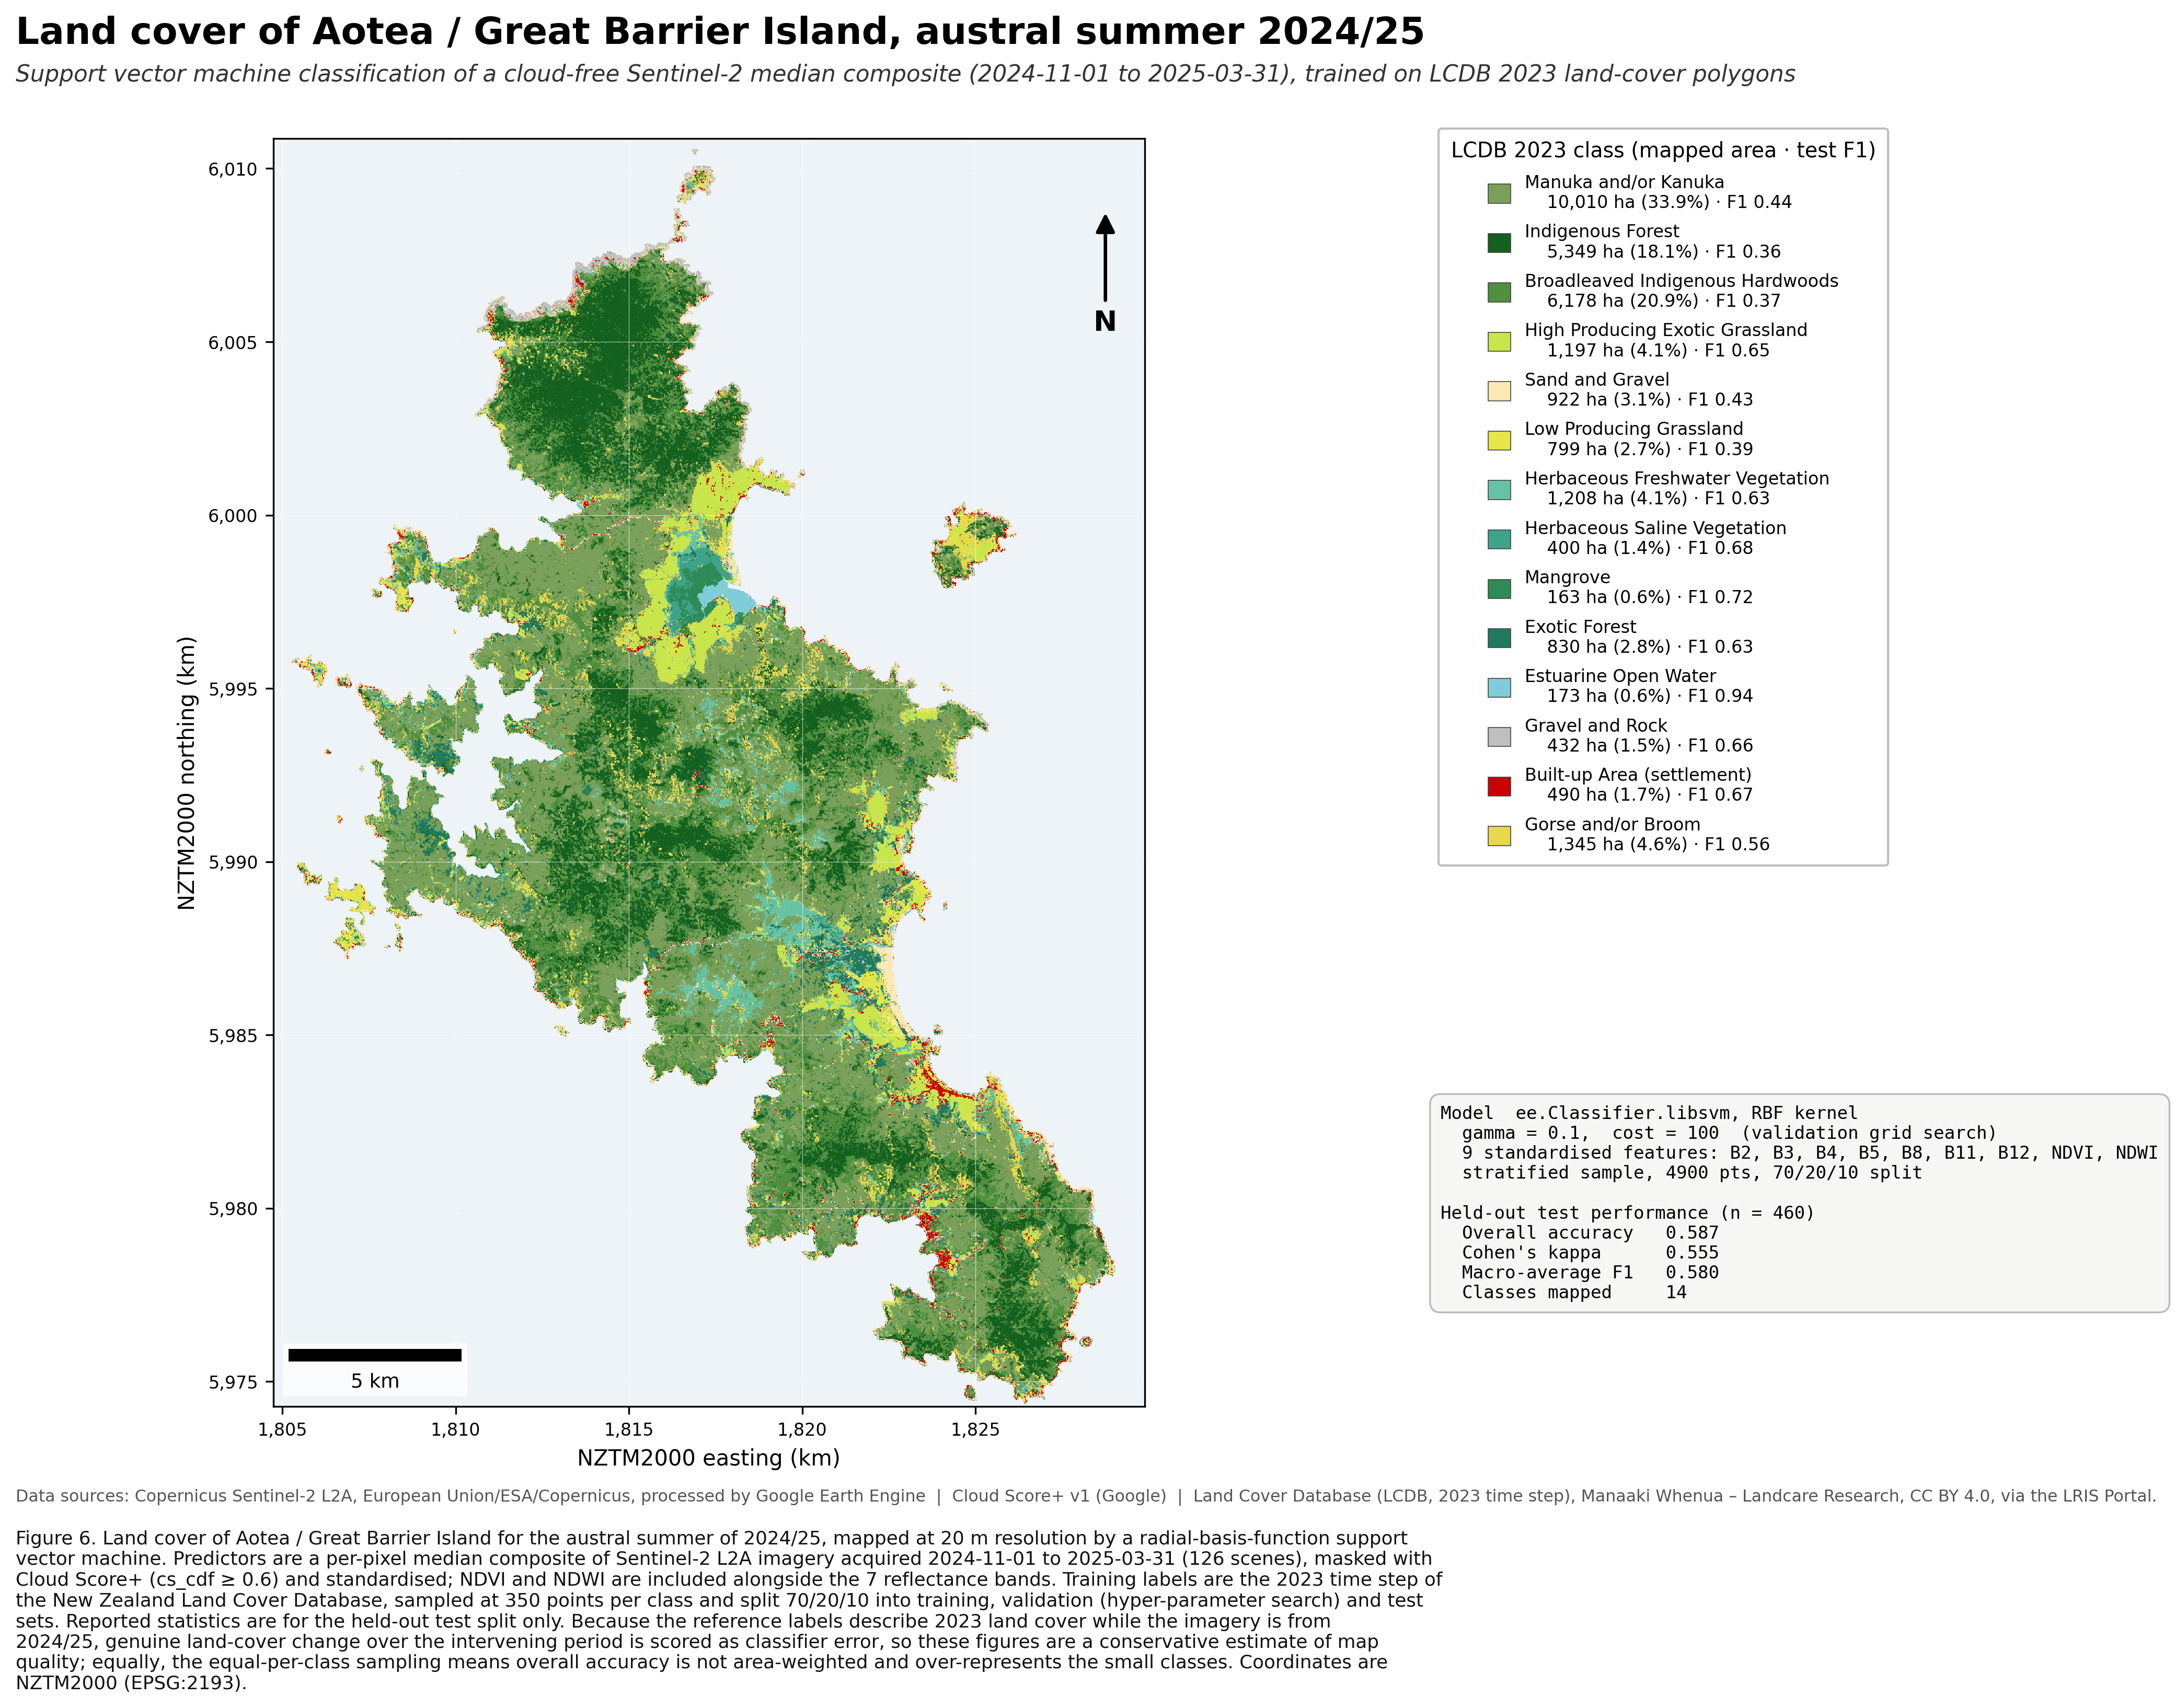

In [64]:
# --- Q6 step 7: the publication-quality figure -------------------------------
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from IPython.display import Image, display

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.linewidth': 0.8})

n_cls  = len(seq_labels)
cmap   = mcolors.ListedColormap([seq_to_colour[s] for s in seq_labels])
cmap.set_bad(alpha=0)                                    # sea stays transparent
norm   = mcolors.BoundaryNorm(np.arange(0.5, n_cls + 1.5), cmap.N)

fig = plt.figure(figsize=(13.5, 10.5))
gs  = fig.add_gridspec(2, 2, width_ratios=[2.55, 1], height_ratios=[3.1, 1],
                       wspace=0.04, hspace=0.05,
                       left=0.055, right=0.985, top=0.90, bottom=0.13)
ax       = fig.add_subplot(gs[:, 0])
side     = fig.add_subplot(gs[0, 1]); side.axis('off')
stats_ax = fig.add_subplot(gs[1, 1]); stats_ax.axis('off')

# ---- the map ---------------------------------------------------------------
ax.imshow(class_arr, cmap=cmap, norm=norm, extent=map_extent,
          origin='upper', interpolation='nearest')
ax.set_aspect('equal')
ax.set_facecolor('#eef3f7')                              # sea
km = FuncFormatter(lambda v, _: f'{v/1000:,.0f}')
ax.xaxis.set_major_formatter(km); ax.yaxis.set_major_formatter(km)
ax.set_xlabel('NZTM2000 easting (km)'); ax.set_ylabel('NZTM2000 northing (km)')
ax.grid(True, lw=0.3, color='white', alpha=0.6)
ax.tick_params(labelsize=8)

# scale bar (axes are in metres, so dx = 1)
ax.add_artist(ScaleBar(1, units='m', location='lower left', length_fraction=0.28,
                       box_alpha=0.75, box_color='white', color='black',
                       scale_loc='bottom', border_pad=0.5,
                       font_properties={'size': 9}))

# north arrow (grid north; NZTM convergence over the island is < 0.4 degrees)
ax.annotate('N', xy=(0.955, 0.945), xytext=(0.955, 0.855),
            xycoords='axes fraction', textcoords='axes fraction',
            ha='center', va='center', fontsize=13, fontweight='bold',
            arrowprops=dict(arrowstyle='-|>', facecolor='black', edgecolor='black',
                            lw=1.6, mutation_scale=18))

# ---- legend, with mapped extent and per-class reliability ------------------
total_ha = sum(area_pred.values())
handles = [mpatches.Patch(facecolor=seq_to_colour[s], edgecolor='#444', lw=0.4,
                          label=f'{seq_to_name[s]}\n'
                                f'    {area_pred[s]:,.0f} ha '
                                f'({100*area_pred[s]/total_ha:.1f}%) · F1 {class_f1[s]:.2f}')
           for s in seq_labels]
side.legend(handles=handles, loc='upper left', bbox_to_anchor=(-0.02, 1.02),
            frameon=True, framealpha=0.95, edgecolor='#bbbbbb', ncol=1,
            title=f'LCDB {LCDB_YEAR} class (mapped area · test F1)',
            title_fontsize=9.5, fontsize=8.0, labelspacing=0.7,
            handlelength=1.3, handleheight=1.3, borderpad=0.7)

stats_txt = (
    'Model  ee.Classifier.libsvm, RBF kernel\n'
    f'  gamma = {GAMMA},  cost = {COST}'
    + ('  (validation grid search)\n' if RUN_GRID_SEARCH else '\n') +
    f'  {len(SVM_FEATURES)} standardised features: '
    f'{", ".join(SR_BANDS)}, NDVI, NDWI\n'
    f'  stratified sample, {n_total} pts, 70/20/10 split\n\n'
    'Held-out test performance (n = '
    f'{len(y_true_svm)})\n'
    f'  Overall accuracy   {overall_acc:.3f}\n'
    f"  Cohen's kappa      {kappa:.3f}\n"
    f'  Macro-average F1   {macro_f1:.3f}\n'
    f'  Classes mapped     {n_cls}')
stats_ax.text(0.0, 1.0, stats_txt, transform=stats_ax.transAxes,
              va='top', ha='left', fontsize=8.2, family='DejaVu Sans Mono',
              bbox=dict(boxstyle='round,pad=0.6', facecolor='#f6f6f4',
                        edgecolor='#bbbbbb', lw=0.8))

# ---- titles, caption, attribution -----------------------------------------
fig.suptitle('Land cover of Aotea / Great Barrier Island, austral summer 2024/25',
             fontsize=17, fontweight='bold', x=0.055, ha='left', y=0.975)
fig.text(0.055, 0.935,
         'Support vector machine classification of a cloud-free Sentinel-2 median '
         f'composite ({SUMMER_START} to {SUMMER_END}), trained on LCDB {LCDB_YEAR} '
         'land-cover polygons',
         fontsize=10.5, ha='left', style='italic', color='#333333')

caption = (
    f'Figure 6. Land cover of Aotea / Great Barrier Island for the austral summer of 2024/25, mapped at '
    f'{MAP_SCALE} m resolution by a radial-basis-function support vector machine. Predictors are a per-pixel median '
    f'composite of Sentinel-2 L2A imagery acquired {SUMMER_START} to {SUMMER_END} '
    f'({s2_scene_count} scenes), masked with Cloud Score+ (cs_cdf \u2265 {CS_THRESHOLD}) and standardised; '
    f'NDVI and NDWI are included alongside the {len(SR_BANDS)} reflectance bands. Training labels are the '
    f'{LCDB_YEAR} time step of the New Zealand Land Cover Database, sampled at {POINTS_PER_CLASS} points per class '
    f'and split 70/20/10 into training, validation (hyper-parameter search) and test sets. Reported statistics are '
    f'for the held-out test split only. Because the reference labels describe {LCDB_YEAR} land cover while the '
    f'imagery is from 2024/25, genuine land-cover change over the intervening period is scored as classifier error, '
    f'so these figures are a conservative estimate of map quality; equally, the equal-per-class sampling means '
    f'overall accuracy is not area-weighted and over-represents the small classes. Coordinates are NZTM2000 '
    f'(EPSG:2193).')
fig.text(0.055, 0.055, '\n'.join(textwrap.wrap(caption, 150)),
         fontsize=8.6, ha='left', va='top', color='#111111')

fig.text(0.055, 0.07,
         'Data sources: Copernicus Sentinel-2 L2A, European Union/ESA/Copernicus, processed by Google Earth Engine  |  '
         f'Cloud Score+ v1 (Google)  |  Land Cover Database (LCDB, {LCDB_YEAR} time step), '
         'Manaaki Whenua \u2013 Landcare Research, CC BY 4.0, via the LRIS Portal.',
         fontsize=7.6, ha='left', va='bottom', color='#555555')

os.makedirs('output_maps', exist_ok=True)
fig_path = 'output_maps/aotea_svm_landcover_2025.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
print('Saved', fig_path)
display(Image(filename=fig_path))